In [ ]:
import scanpy as sc
from matplotlib import pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

adata = sc.read_h5ad("xenium5k_scVI_CellCharter_batch2_reannot.h5ad")
path = " " #path to folder for saving figures

In [3]:
adata 

AnnData object with n_obs × n_vars = 2131098 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden', 'megagut_lvl3_predicted_labels', 'megagut_lvl3_over_clustering', 'megagut_lvl3_majority_voting', 'megagut_lvl3_conf_score', 'megagut_lvl1_predicted_labels', 'megagut_lvl1_over_clustering', 'megagut_lvl1_majority_voting', 'megagut_lvl1_conf_score', 'fibro_predicted_labels', 'fibro_over_clustering', 'fibro_majority_voting', 'fibro_conf_score', 'MF1_prob', 'MF2_prob', 'PC_prob', 'S1_prob', 'S2_prob', 'S3_prob', 'S3x_prob', 'S4_prob',

In [4]:
adata = adata[adata.obs.transcript_counts >= 100]

In [5]:
cluster = adata.obs['spatial_cluster15']
sample = adata.obs["sample"]
celltype = adata.obs["annot"]

In [6]:
sample.cat.categories

Index(['0033516_adjacent', '0033516_affected', '0043587_adjacent',
       '0043587_affected', '0054175__GI10072_CD_adj',
       '0054175__GI_10072_CD_inf', '0054433__GI9676_CD_adj',
       '0054433__GI9676_CD_inf', '0060032__gi9662_inf', '0060032__gi9662_nor',
       '0060032__gi10056_inf', '0060032__gi10056_nor', '0072732__CD10500INF',
       '0072732__CD10500NOR', '0072926__CD9623INF', '0072926__CD9623NOR'],
      dtype='object')

In [7]:
inf = ['0033516_affected','0043587_affected','0054175__GI_10072_CD_inf','0054433__GI9676_CD_inf','0072732__CD10500INF','0072926__CD9623INF','0060032__gi9662_inf','0060032__gi10056_inf']

not_inf = ['0033516_adjacent', '0043587_adjacent','0054175__GI10072_CD_adj','0054433__GI9676_CD_adj', '0060032__gi9662_nor', '0060032__gi10056_nor',
       '0072732__CD10500NOR', '0072926__CD9623NOR']

In [8]:
patients = {'0033516_affected': '0033516',
 '0033516_adjacent': '0033516',
 '0043587_affected': '0043587',
 '0043587_adjacent': '0043587',
 '0054175__GI_10072_CD_inf': '0054175',
 '0054175__GI10072_CD_adj': '0054175',
 '0054433__GI9676_CD_inf': '0054433',
 '0054433__GI9676_CD_adj': '0054433',
 '0060032__gi9662_inf': '0060032_1',
 '0060032__gi9662_nor': '0060032_1',
 '0060032__gi10056_inf': '0060032_2',
 '0060032__gi10056_nor': '0060032_2',
 '0072732__CD10500INF': '0072732',
 '0072732__CD10500NOR': '0072732',
 '0072926__CD9623INF': '0072926',
 '0072926__CD9623NOR': '0072926'}

In [9]:
cross = pd.crosstab(sample.values, cluster.values, rownames = ["samples"], colnames=["clusters"], normalize = "index")

for sample_id in cross.index:
    if sample_id in inf:
        cross.loc[f"{sample_id}","status"] = "Inflamed"
    else:
        cross.loc[f"{sample_id}","status"] = "Adjacent"
cross["patient"] = cross.index.map(patients)

cross

clusters,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,status,patient
samples,,,,,,,,,,,,,,,,,
0033516_adjacent,0.223388,0.049040,0.000000,0.115559,0.024793,0.203656,0.000000,0.000000,0.014578,0.038129,0.084452,0.000209,0.003784,0.153677,0.088735,Adjacent,0033516
0033516_affected,0.000000,0.201339,0.094369,0.067253,0.073347,0.051821,0.000847,0.096264,0.002813,0.086037,0.027015,0.051756,0.134667,0.003873,0.108599,Inflamed,0033516
0043587_adjacent,0.220946,0.042185,0.000000,0.136182,0.000079,0.263210,0.004222,0.000000,0.053826,0.005091,0.061994,0.000079,0.004656,0.169291,0.038238,Adjacent,0043587
0043587_affected,0.000363,0.110145,0.020551,0.038352,0.002498,0.003918,0.054609,0.242113,0.020337,0.108978,0.020759,0.153609,0.114232,0.003535,0.106000,Inflamed,0043587
0054175__GI10072_CD_adj,0.324697,0.008976,0.000000,0.038696,0.054749,0.124019,0.000312,0.000041,0.103573,0.016080,0.088197,0.000122,0.000054,0.219226,0.021260,Adjacent,0054175
0054175__GI_10072_CD_inf,0.007414,0.083598,0.004453,0.092738,0.223661,0.171789,0.002328,0.004625,0.037170,0.063716,0.098105,0.020132,0.023804,0.049834,0.116635,Inflamed,0054175
0054433__GI9676_CD_adj,0.027592,0.164527,0.000403,0.027120,0.003363,0.009339,0.001543,0.311307,0.006196,0.036620,0.135184,0.039718,0.057936,0.118360,0.060792,Adjacent,0054433
0054433__GI9676_CD_inf,0.000442,0.151932,0.001871,0.025885,0.011969,0.001655,0.011578,0.451879,0.002626,0.049560,0.002158,0.123436,0.100615,0.000596,0.063800,Inflamed,0054433
0060032__gi9662_inf,0.045374,0.117262,0.011426,0.104654,0.004713,0.021720,0.033055,0.091219,0.011997,0.091814,0.077172,0.012625,0.198642,0.083224,0.095105,Inflamed,0060032_1


# Boxplots of niche cell number abundance, with t-test

In [10]:
def abundance_niche(niche_nr, plottype = "boxplot", ax = None):
    
    niche = cross.loc[:,[f"{niche_nr}","status","patient"]]
    
    niche_inf = niche[niche["status"] == "Inflamed"][f"{niche_nr}"].to_numpy()

    niche_not_inf = niche[niche["status"] == "Adjacent"][f"{niche_nr}"].to_numpy()

    t_statistic, p_value = stats.ttest_rel(niche_inf, niche_not_inf)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
        if plottype == "boxplot":
        
            plot = sns.boxplot(
                    data=niche,
                    x="status",
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "status",
                    hue_order=["Inflamed", "Adjacent"],
                    width=0.3, 
                    fliersize = 0,
                    ax = ax
                )
            sns.stripplot(data=niche, 
                    x="status", 
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    hue="status", 
                    hue_order=["Inflamed", "Adjacent"],
                    #dodge=True, 
                    jitter = False,
                    ax=ax)
            
            sns.lineplot(data=niche,
                        x="status",
                        y=f"{niche_nr}", 
                        sort = False,
                        estimator = None,
                        units = "patient",
                        #hue = "patient",
                        legend = False,
                        color=".7",
                        ax=ax)
            
        if plottype == "violinplot":
            plot = sns.violinplot(
                    data=niche,
                    x="status",
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "status",
                    hue_order=["Inflamed", "Adjacent"],
                    width=0.3, 
                    ax = ax
                )
            
        plot.set_xlabel("Sample status")
        plot.set_ylabel(f"Relative cell abundance of niche {niche_nr}")
        plot.set_title(f"Niche {niche_nr}, p-value: {p_value:.3f}, t-statistic: {t_statistic:.3f}")

        plt.suptitle("")
        plt.savefig(f"{path}/{plottype}/{plottype}_cluster{niche_nr}.png", dpi = 300, bbox_inches = "tight")
    
    else:
        if plottype == "boxplot":
        
            plot = sns.boxplot(
                    data=niche,
                    x="status",
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "status",
                    width=0.3,
                    hue_order=["Inflamed", "Adjacent"],
                    dodge = False,
                    fliersize = 0,
                    ax = ax
                )
                        
            sns.stripplot(data=niche, 
                    x="status", 
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    hue="status", 
                    hue_order=["Inflamed", "Adjacent"],
                    #dodge=True, 
                    jitter = False,
                    ax=ax)
            
            sns.lineplot(data=niche,
                    x="status",
                    y=f"{niche_nr}", 
                    sort = False,
                    estimator = None,
                    units = "patient",
                    #hue = "patient",
                    legend = False,
                    color=".7",
                    ax=ax)
            
        if plottype == "violinplot":
            plot = sns.violinplot(
                    data=niche,
                    x="status",
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "status",
                    hue_order=["Inflamed", "Adjacent"],
                    width=0.3,
                    ax = ax
                )

        plot.set_xlabel("Sample status")
        plot.set_ylabel(f"Relative cell abundance of niche {niche_nr}")
        plot.set_title(f"Niche {niche_nr}, p-value: {p_value:.3f}, t-statistic: {t_statistic:.3f}")

        

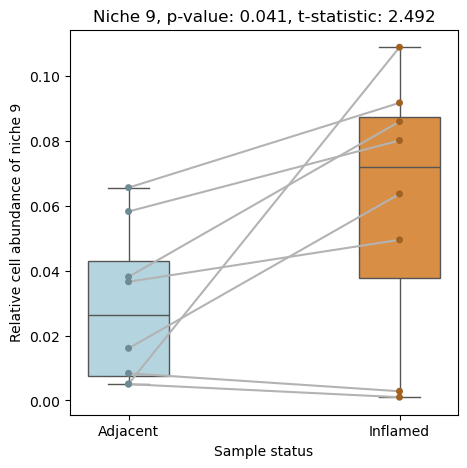

In [11]:
abundance_niche(9)

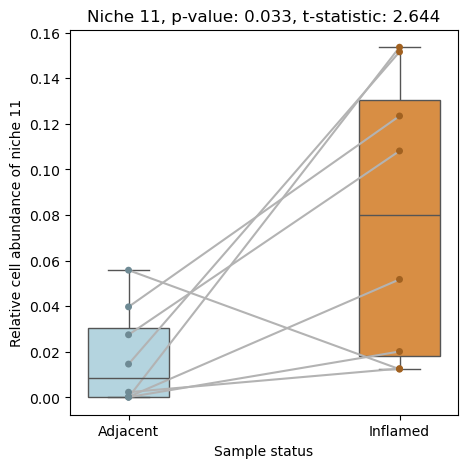

In [12]:
abundance_niche(11, plottype = "boxplot")

In [13]:
def subplots(plottype = "boxplot", niche_order = None):
    fig, axes = plt.subplots(4,4, figsize=(18,20))
    axes = axes.flatten()
    
    if niche_order is None: 
        for i in range(15):
            abundance_niche(i, plottype = plottype, ax = axes[i])

    else:
        for i, niche in enumerate(niche_order):
            abundance_niche(niche, plottype = plottype, ax = axes[i])

    last_plot = axes[15]
    last_plot.axis("off") #Remove empty plot

    fig.tight_layout()
    if niche_order is None:
        plt.savefig(f"{path}/{plottype}/{plottype}_all_clusters.png", dpi = 300, bbox_inches = "tight")
    else:
        plt.savefig(f"{path}/{plottype}/{plottype}_all_clusters_ordered.png", dpi = 300, bbox_inches = "tight")


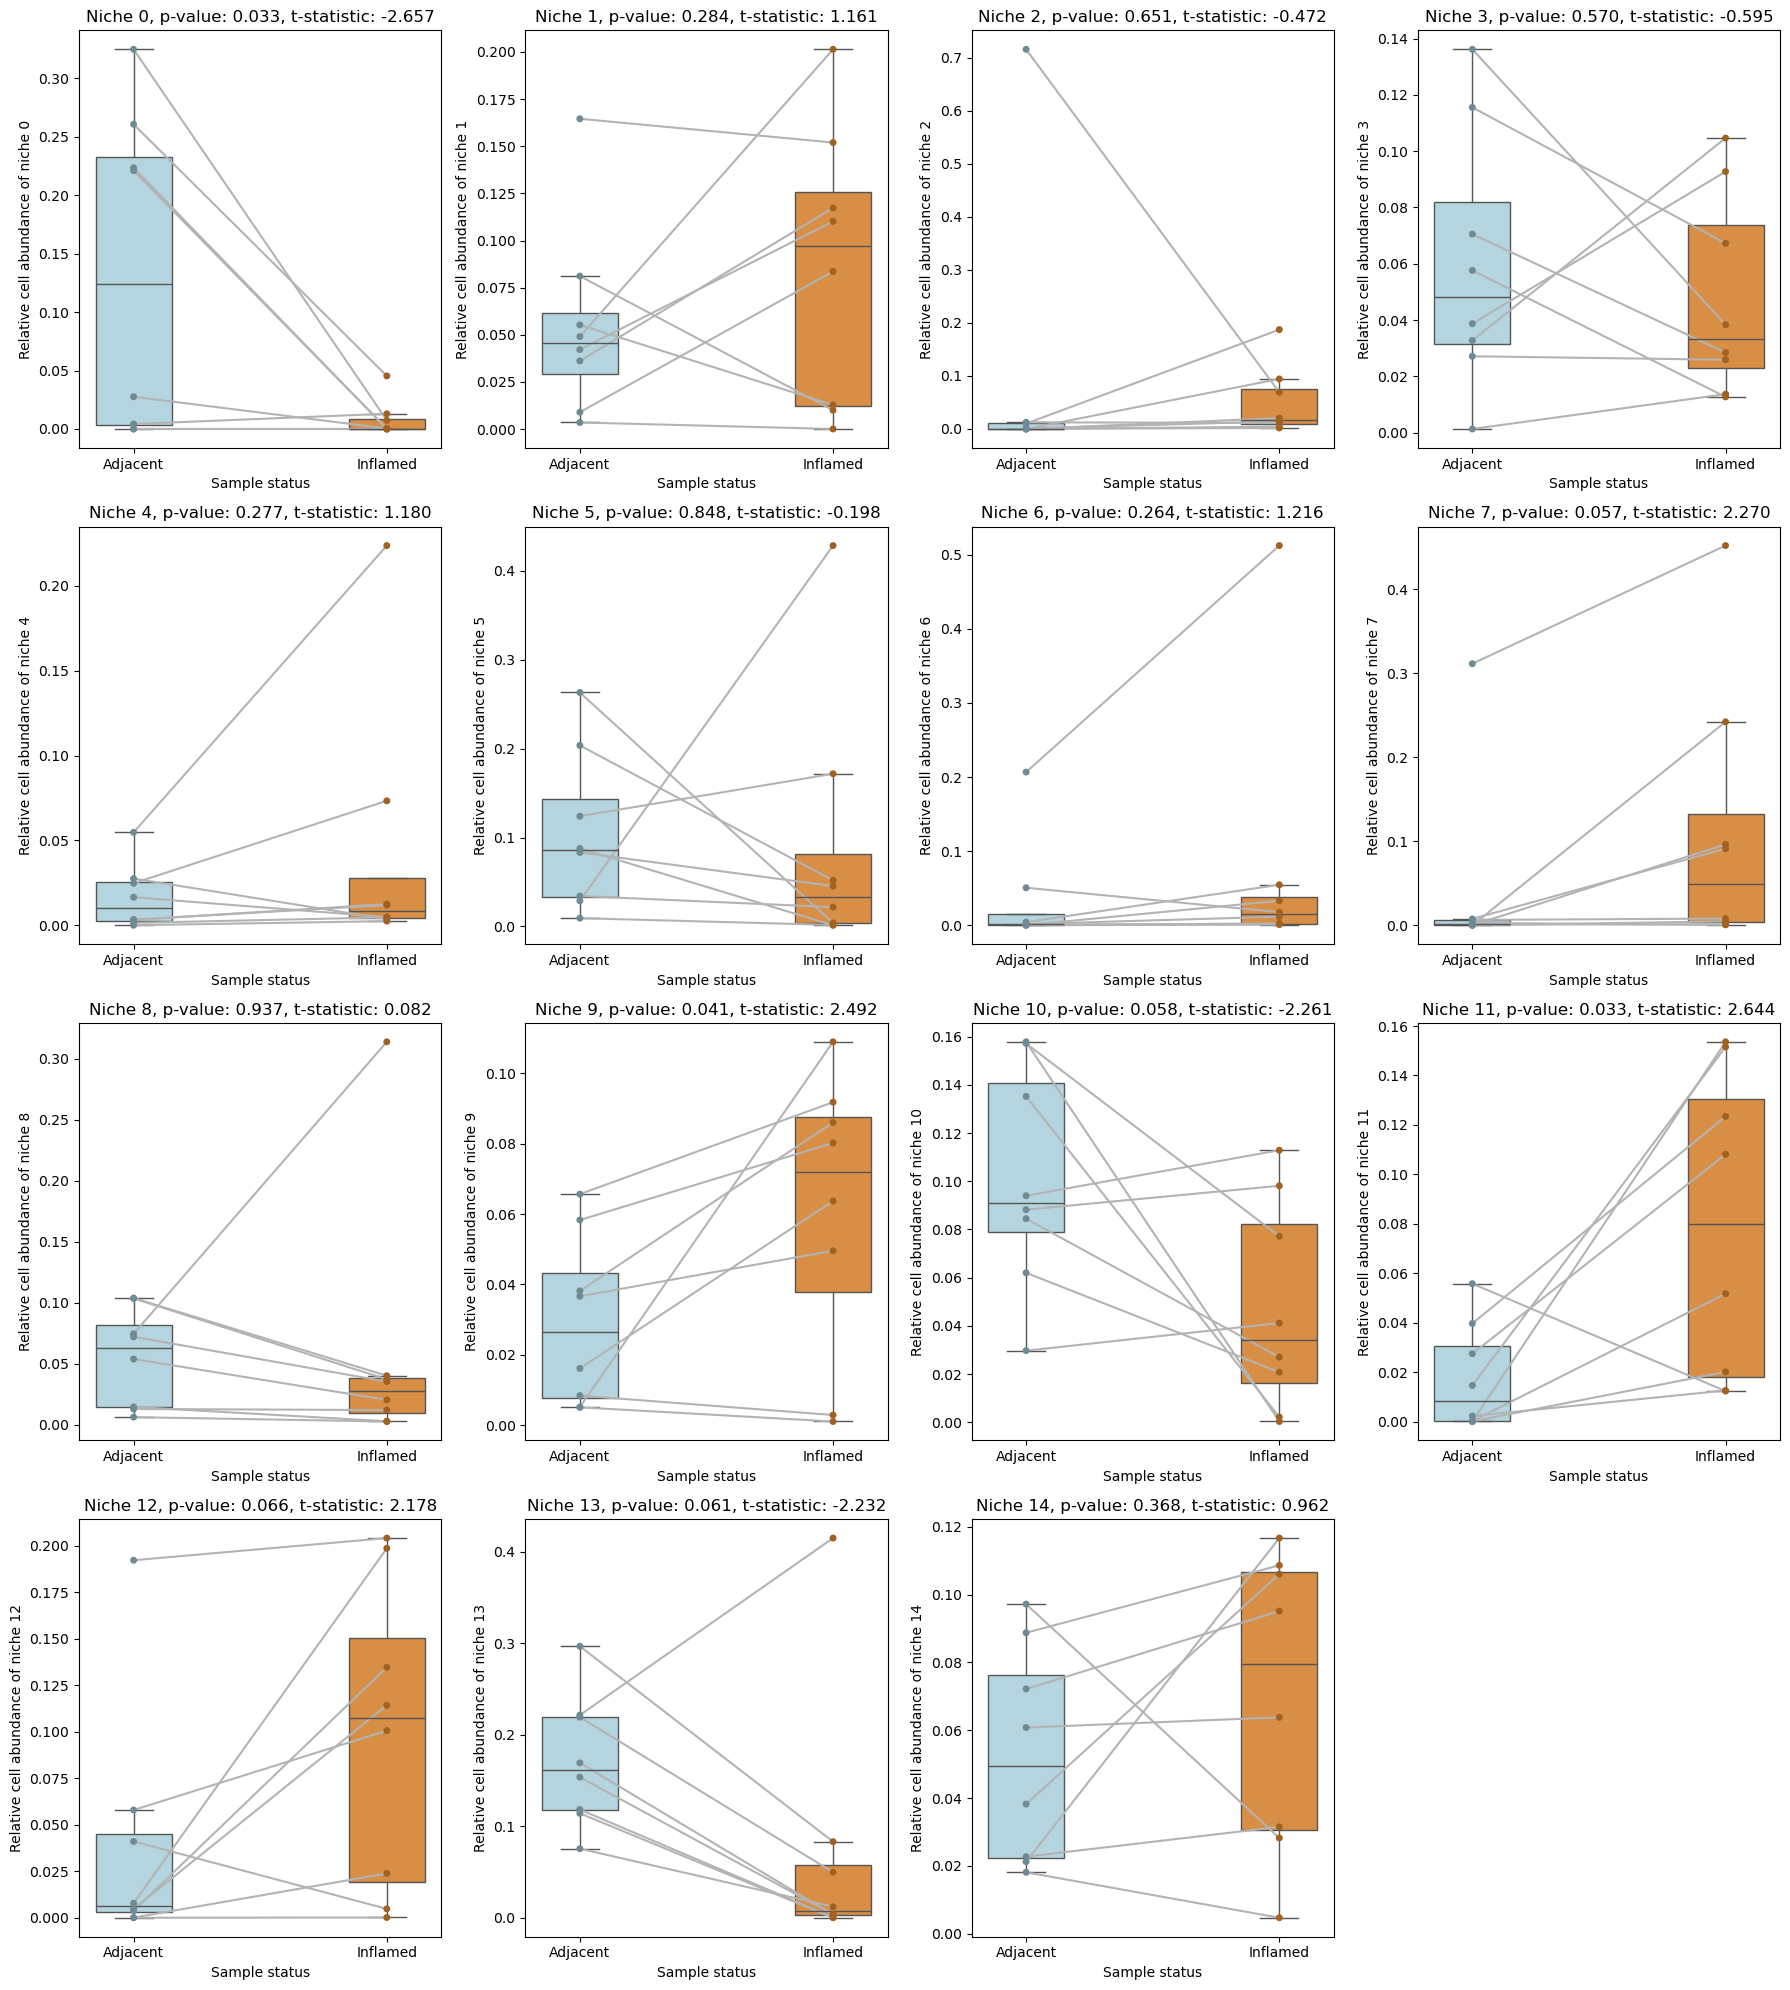

In [14]:
subplots()

# Dataframes with statistics of each niche in inflamed vs not inflamed samples

## Parametric testing, t-test

In [15]:
niche_stats_df = pd.DataFrame(columns=["p_value", "t_statistic", "mean_inflamed", "mean_not_inflamed"])

for i in range(15):
    niche = cross.loc[:,[f"{i}","status"]]
    
    niche_inf = niche[niche["status"] == "Inflamed"][f"{i}"].to_numpy()

    niche_not_inf = niche[niche["status"] == "Adjacent"][f"{i}"].to_numpy()

    t_statistic, p_value = stats.ttest_rel(niche_inf, niche_not_inf)

    mean_niche_inf = round(niche_inf.mean(),3)
    mean_niche_not_inf = round(niche_not_inf.mean(), 3)

    niche_stats_df.loc[i] = [p_value, t_statistic, mean_niche_inf, mean_niche_not_inf]

niche_stats_df

,p_value,t_statistic,mean_inflamed,mean_not_inflamed
0,0.032592,-2.657349,0.008,0.133
1,0.283690,1.161022,0.086,0.055
2,0.651412,-0.471814,0.050,0.093
3,0.570297,-0.595430,0.048,0.060
4,0.276542,1.180000,0.042,0.016
5,0.848303,-0.198490,0.091,0.104
6,0.263534,1.215613,0.079,0.033
7,0.057499,2.269744,0.112,0.041
8,0.936956,0.081982,0.058,0.055
9,0.041484,2.491845,0.061,0.029


In [16]:
#ordered according to t-statistic
niche_stats_df_sorted = niche_stats_df.sort_values(by = "t_statistic", ascending = False, key = abs)
niches_significance_sorting = niche_stats_df_sorted.index.tolist()
niche_stats_df_sorted

,p_value,t_statistic,mean_inflamed,mean_not_inflamed
0,0.032592,-2.657349,0.008,0.133
11,0.033245,2.643690,0.079,0.018
9,0.041484,2.491845,0.061,0.029
7,0.057499,2.269744,0.112,0.041
10,0.058207,-2.261452,0.047,0.101
13,0.060751,-2.232448,0.071,0.171
12,0.065874,2.177597,0.098,0.038
6,0.263534,1.215613,0.079,0.033
4,0.276542,1.180000,0.042,0.016
1,0.283690,1.161022,0.086,0.055


## Non-parametric testing, wilcoxon

In [17]:
niche_stats_df_nonp = pd.DataFrame(columns=["p_value", "wilcoxon_statistic", "mean_inflamed", "mean_not_inflamed"])

for i in range(15):
    niche = cross.loc[:,[f"{i}","status"]]
    
    niche_inf = niche[niche["status"] == "Inflamed"][f"{i}"].to_numpy()

    niche_not_inf = niche[niche["status"] == "Adjacent"][f"{i}"].to_numpy()

    statistic, p_value = stats.wilcoxon(niche_inf, niche_not_inf)

    mean_niche_inf = round(niche_inf.mean(),3)
    mean_niche_not_inf = round(niche_not_inf.mean(), 3)

    niche_stats_df_nonp.loc[i] = [p_value, statistic, mean_niche_inf, mean_niche_not_inf]

niche_stats_df_nonp

,p_value,wilcoxon_statistic,mean_inflamed,mean_not_inflamed
0,0.062500,1.0,0.008,0.133
1,0.382812,11.0,0.086,0.055
2,0.250000,9.0,0.050,0.093
3,0.742188,15.0,0.048,0.060
4,0.382812,11.0,0.042,0.016
5,0.460938,12.0,0.091,0.104
6,0.109375,6.0,0.079,0.033
7,0.039062,3.0,0.112,0.041
8,0.195312,8.0,0.058,0.055
9,0.039062,3.0,0.061,0.029


In [18]:
#Ordered according to p-value
niche_stats_df_nonp_sorted = niche_stats_df_nonp.sort_values(by = "p_value", ascending = True, key = abs)
niches_significance_nonp_sorting = niche_stats_df_nonp_sorted.index.tolist()
niche_stats_df_nonp_sorted

,p_value,wilcoxon_statistic,mean_inflamed,mean_not_inflamed
7,0.039062,3.0,0.112,0.041
9,0.039062,3.0,0.061,0.029
11,0.039062,3.0,0.079,0.018
12,0.054688,4.0,0.098,0.038
0,0.062500,1.0,0.008,0.133
10,0.109375,6.0,0.047,0.101
6,0.109375,6.0,0.079,0.033
13,0.148438,7.0,0.071,0.171
8,0.195312,8.0,0.058,0.055
2,0.250000,9.0,0.050,0.093


# Ordered boxplots according to significance (t-test)

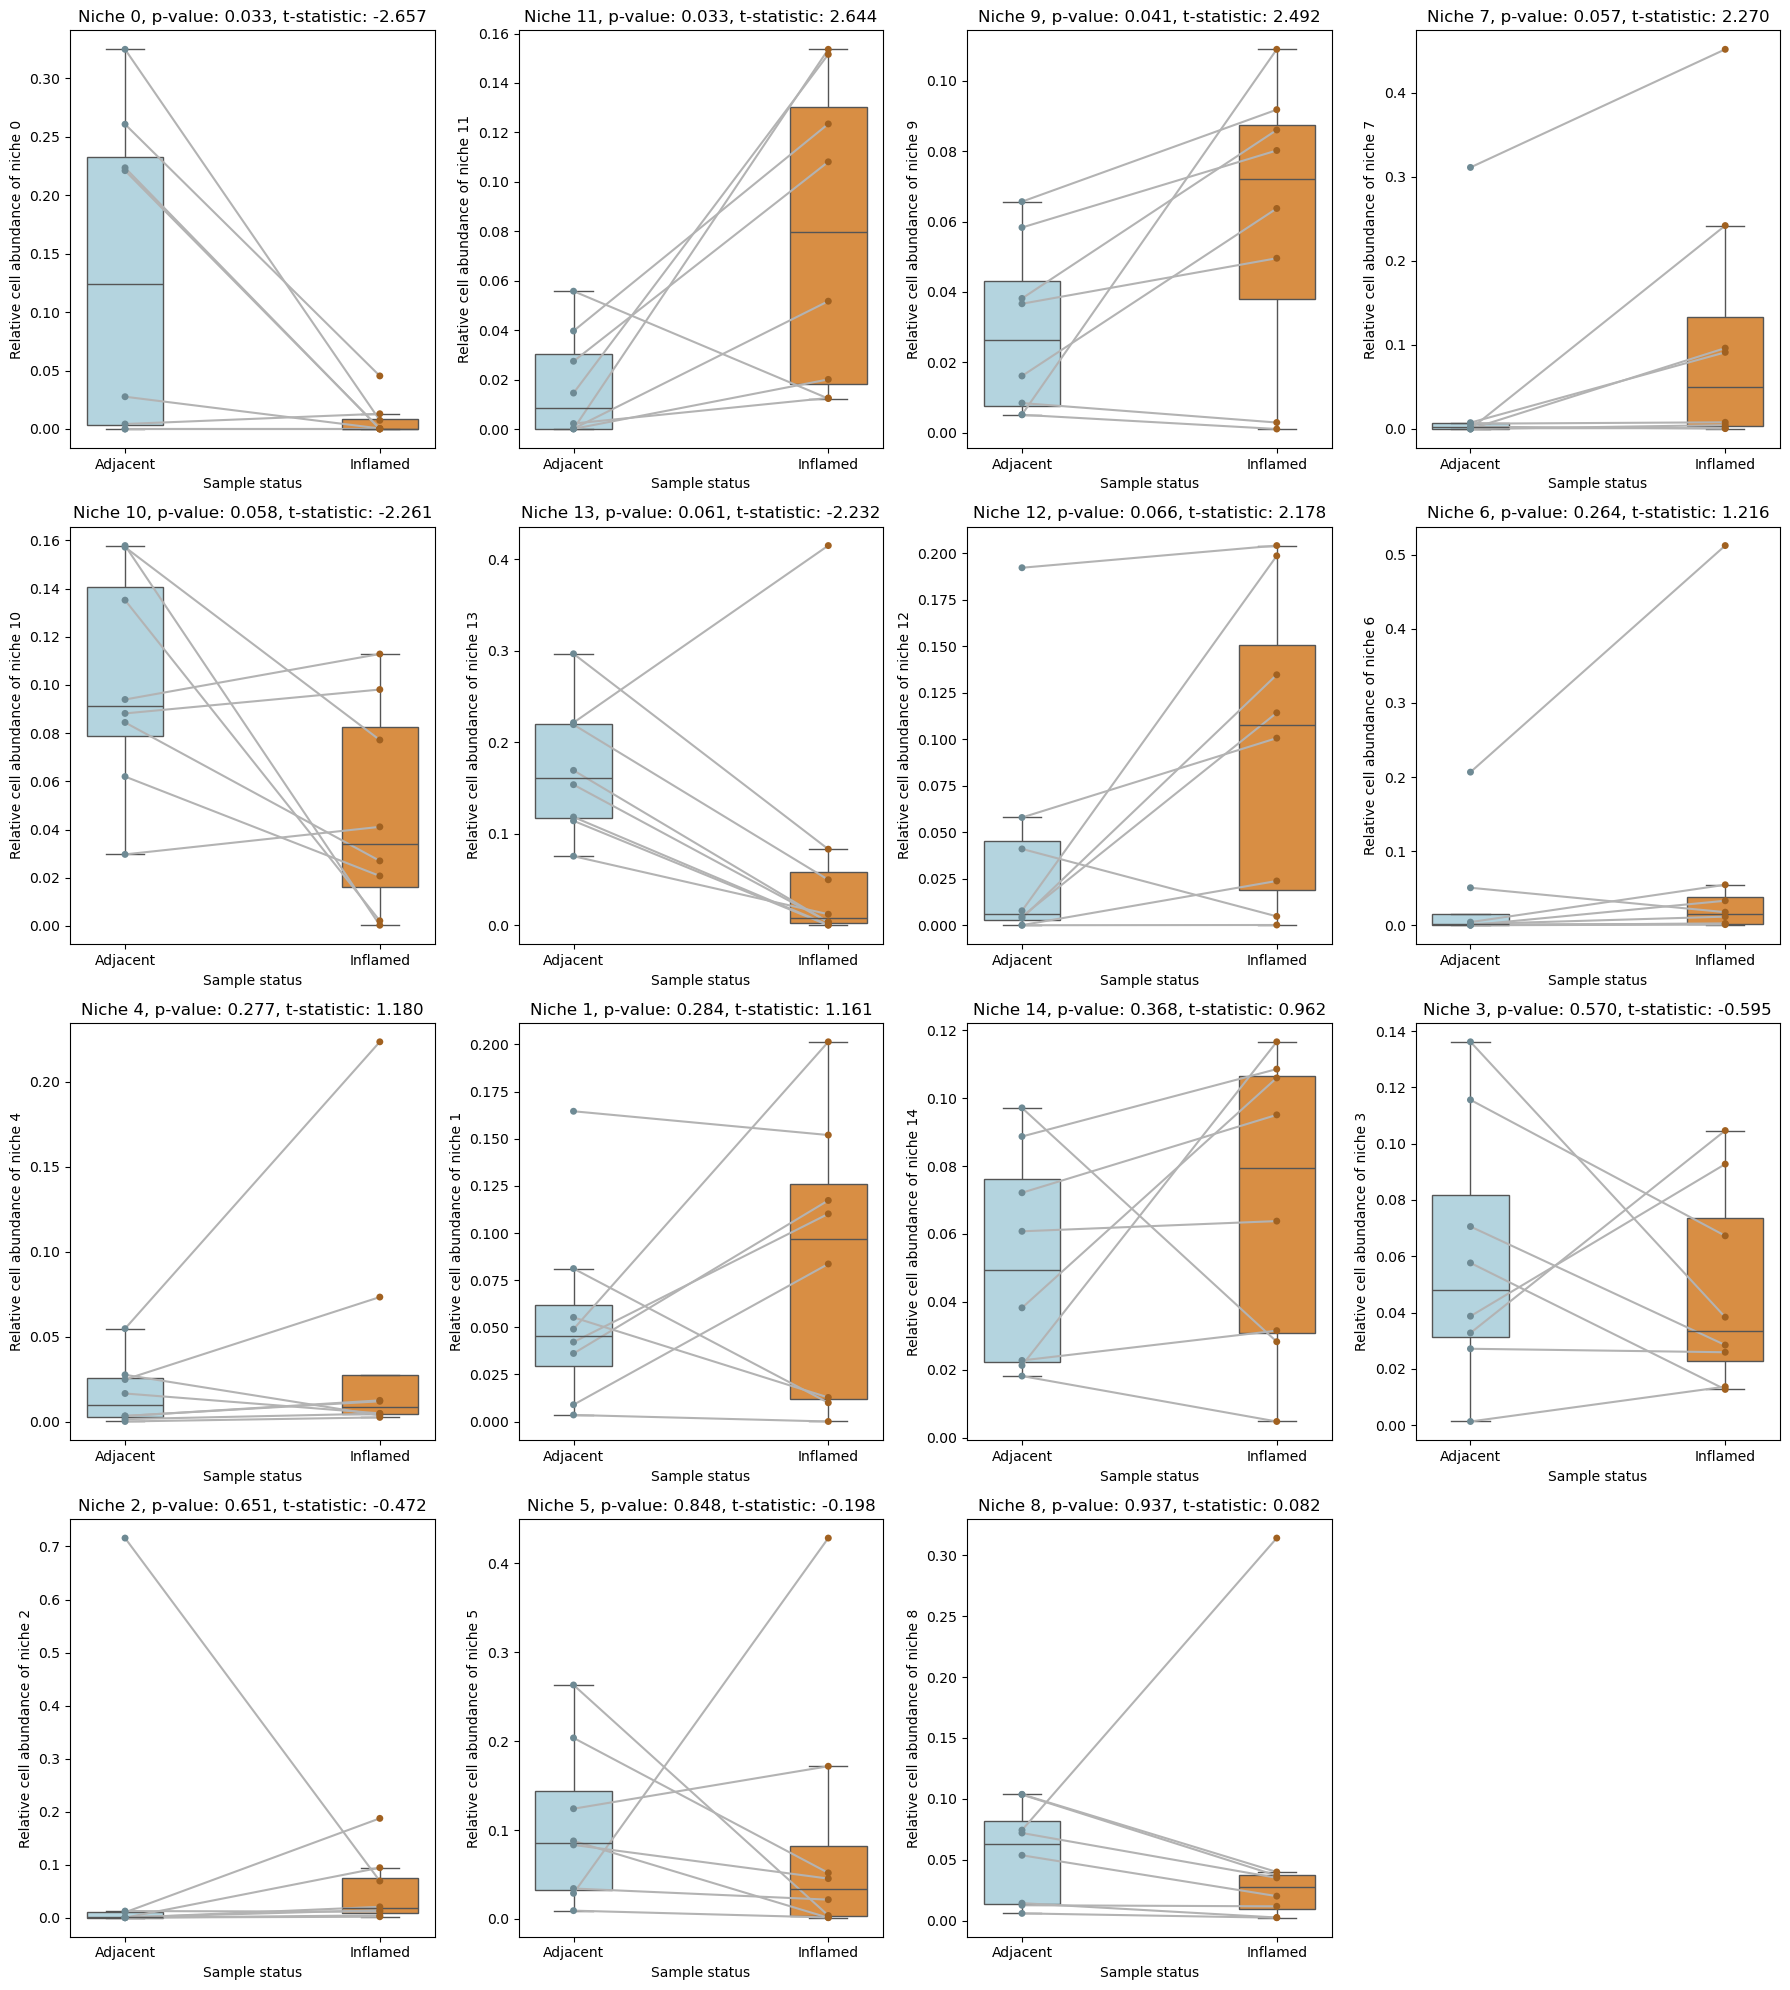

In [19]:
subplots(niche_order = niches_significance_sorting)

## All boxplots in one plot ordered according to t-statistic

In [20]:
cross_melt = cross.drop("patient", axis=1).melt(
    id_vars=["status"],
    value_name="Proportion of niche",
    ignore_index = False
)

cross_melt = cross_melt.rename(columns = {"clusters": "Niche","status":"Status"})
cross_melt

,Status,Niche,Proportion of niche
samples,,,
0033516_adjacent,Adjacent,0,0.223388
0033516_affected,Inflamed,0,0.000000
0043587_adjacent,Adjacent,0,0.220946
0043587_affected,Inflamed,0,0.000363
0054175__GI10072_CD_adj,Adjacent,0,0.324697
...,...,...,...
0060032__gi10056_nor,Adjacent,14,0.097170
0072732__CD10500INF,Inflamed,14,0.031513
0072732__CD10500NOR,Adjacent,14,0.022738


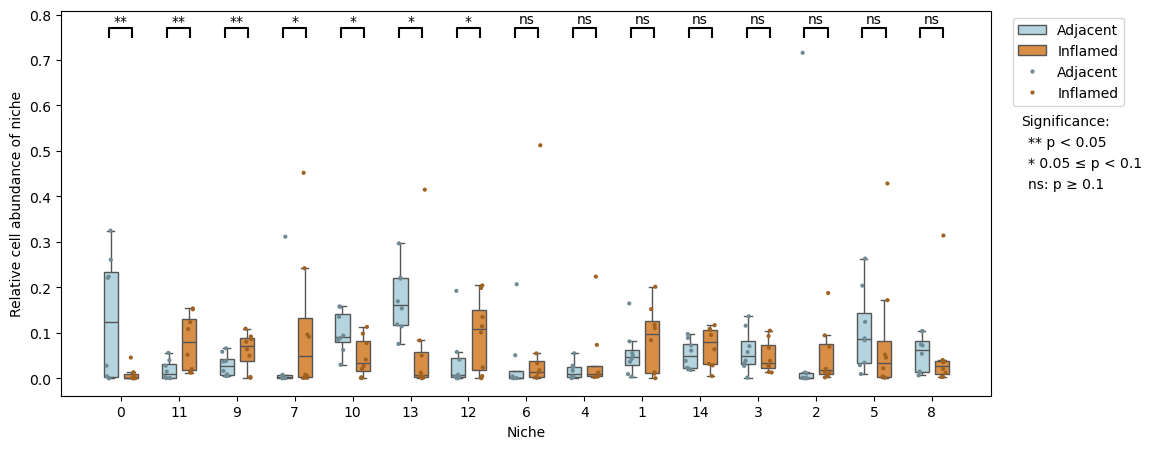

In [21]:
fig, ax = plt.subplots(figsize=(12,5))

plot = sns.boxplot(data=cross_melt,
                    x="Niche",
                    y="Proportion of niche",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "Status",
                    width=0.7,
                    gap = 0.3,
                    ax = ax, 
                    order = niches_significance_sorting,
                    hue_order=["Adjacent", "Inflamed"],
                    fliersize = 0,
                    #linecolor = "black"
                )
            
sns.stripplot(data=cross_melt, 
                    x="Niche", 
                    y="Proportion of niche",
                    palette= {"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    size = 3,
                    hue="Status", 
                    dodge=True, 
                    ax=ax,
                    order = niches_significance_sorting,
                    hue_order=["Adjacent", "Inflamed"],
                    )

plot.set_ylabel(f"Relative cell abundance of niche")

x = 1.15

first_legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(x,1.0)
)

for i, niche in enumerate(niches_significance_sorting):
    x1 = i - 0.2
    x2 = i + 0.2
    y =  0.75 #max(cross_melt[cross_melt["Niche"] == f"{niche}"]["Proportion of niche"]) + 0.07
    h = 0.02
    col = "k"
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    if niche_stats_df.loc[niche, "p_value"] < 0.05:  
        text = "**"
        h2 = h
    elif niche_stats_df.loc[niche, "p_value"] < 0.1:  
        text = "*"
        h2 = h
    elif niche_stats_df.loc[niche, "p_value"] >= 0.1:  
        text = "ns"
        h2 = 0.025
    ax.text(i,y+h2,text,ha="center", va = "bottom", c = col)

line1, = ax.plot([], [], alpha = 0, label='** p < 0.05')
line2, = ax.plot([], [], alpha = 0, label='* 0.05 ≤ p < 0.1')
line3, = ax.plot([], [], alpha = 0, label='ns: p ≥ 0.1')

second_legend = plt.legend(handles=[line1, line2, line3],title = "Significance:",loc='lower right', bbox_to_anchor = (x+0.025, 0.5), frameon=False)

ax.add_artist(first_legend)

#table = pd.plotting.table(axes[1], niche_stats_df_sorted.round(3), loc="center", cellLoc="center")

plt.savefig(f"{path}/boxplot/boxplot_all_clusters_one_plot.png", dpi = 300, bbox_inches = "tight")

# Ordered boxplots according to significance (wilcoxon)

In [22]:
def abundance_niche_np(niche_nr, ax = None):
    
    niche = cross.loc[:,[f"{niche_nr}","status","patient"]]
    
    niche_inf = niche[niche["status"] == "Inflamed"][f"{niche_nr}"].to_numpy()

    niche_not_inf = niche[niche["status"] == "Adjacent"][f"{niche_nr}"].to_numpy()

    statistic, p_value = stats.wilcoxon(niche_inf, niche_not_inf)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
        
        plot = sns.boxplot(
                data=niche,
                x="status",
                y=f"{niche_nr}",
                palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                hue = "status",
                hue_order=["Inflamed", "Adjacent"],
                width=0.3, 
                fliersize = 0,
                ax = ax
            )
        sns.stripplot(data=niche, 
                x="status", 
                y=f"{niche_nr}",
                palette={"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                hue="status", 
                hue_order=["Inflamed", "Adjacent"],
                #dodge=True, 
                jitter = False,
                ax=ax)
        
        sns.lineplot(data=niche,
                    x="status",
                    y=f"{niche_nr}", 
                    sort = False,
                    estimator = None,
                    units = "patient",
                    #hue = "patient",
                    legend = False,
                    color=".7",
                    ax=ax)
            
        plot.set_xlabel("Sample status")
        plot.set_ylabel(f"Relative cell abundance of niche {niche_nr}")
        plot.set_title(f"Differential relative abundance of niche {niche_nr} \n (paired two-tailed Wilcoxon test)") #, p-value: {p_value:.3f}, wilcoxon statistic: {statistic:.1f}")

        x1 = 0
        x2 = 1
        y =  max(cross_melt[cross_melt["Niche"] == f"{niche_nr}"]["Proportion of niche"])
        y = y +y*0.1
        h = y*0.1
        col = "k"
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
        if niche_stats_df_nonp.loc[niche_nr, "p_value"] < 0.05:  
            text = "**"
            h2 = h
        elif niche_stats_df_nonp.loc[niche_nr, "p_value"] < 0.1:  
            text = "*"
            h2 = h
        elif niche_stats_df_nonp.loc[niche_nr, "p_value"] >= 0.1:  
            text = "ns"
            h2 = 0.025
        ax.text(0.5,y+h2,text,ha="center", va = "bottom", c = col)

        line1, = ax.plot([], [], alpha = 0, label='** p < 0.05')
        line2, = ax.plot([], [], alpha = 0, label='* 0.05 ≤ p < 0.1')
        line3, = ax.plot([], [], alpha = 0, label='ns: p ≥ 0.1')

        ax.legend(handles=[line1, line2, line3],title = "Significance:",loc='lower right', bbox_to_anchor = (1.4, 0.5), frameon=False)

        plt.suptitle("")
        plt.savefig(f"{path}/boxplot/boxplot_cluster{niche_nr}_nonp.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
    
    else:
        plot = sns.boxplot(
                    data=niche,
                    x="status",
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "status",
                    width=0.3,
                    hue_order=["Inflamed", "Adjacent"],
                    dodge = False,
                    fliersize = 0,
                    ax = ax
                )
                        
        sns.stripplot(data=niche, 
                    x="status", 
                    y=f"{niche_nr}",
                    palette={"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    hue="status", 
                    hue_order=["Inflamed", "Adjacent"],
                    #dodge=True, 
                    jitter = False,
                    ax=ax)
            
        sns.lineplot(data=niche,
                    x="status",
                    y=f"{niche_nr}", 
                    sort = False,
                    estimator = None,
                    units = "patient",
                    #hue = "patient",
                    legend = False,
                    color=".7",
                    ax=ax)

        plot.set_xlabel("Sample status")
        plot.set_ylabel(f"Relative cell abundance of niche {niche_nr}")
        plot.set_title(f"Niche {niche_nr}, p-value: {p_value:.3f}, wilcoxon statistic: {statistic:.1f}")

        

In [23]:
def subplots_np(niche_order = None):
    fig, axes = plt.subplots(4,4, figsize=(18,20))
    axes = axes.flatten()
    
    if niche_order is None: 
        for i in range(15):
            abundance_niche_np(i, ax = axes[i])

    else:
        for i, niche in enumerate(niche_order):
            abundance_niche_np(niche, ax = axes[i])

    last_plot = axes[15]
    last_plot.axis("off") #Remove empty plot

    fig.tight_layout()
    if niche_order is None:
        plt.savefig(f"{path}/boxplot/boxplot_all_clusters_nonparametric.png", dpi = 300, bbox_inches = "tight")
    else:
        plt.savefig(f"{path}/boxplot/boxplot_all_clusters_ordered_nonparametric.png", dpi = 300, bbox_inches = "tight")

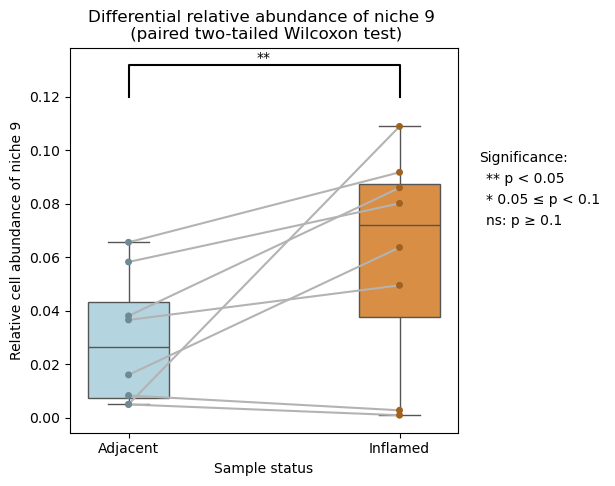

In [24]:
abundance_niche_np(9)

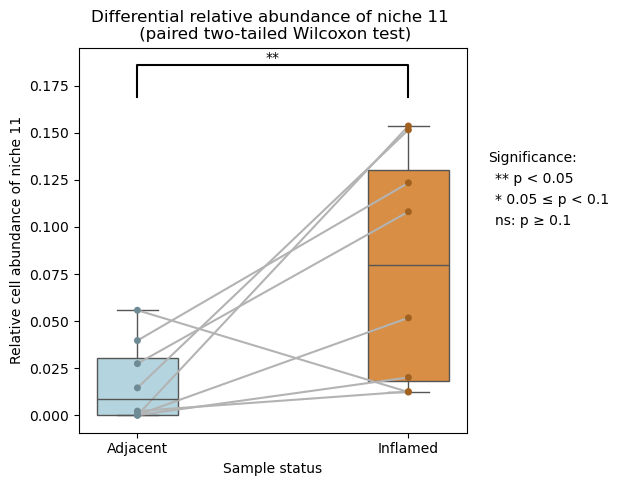

In [25]:
abundance_niche_np(11)

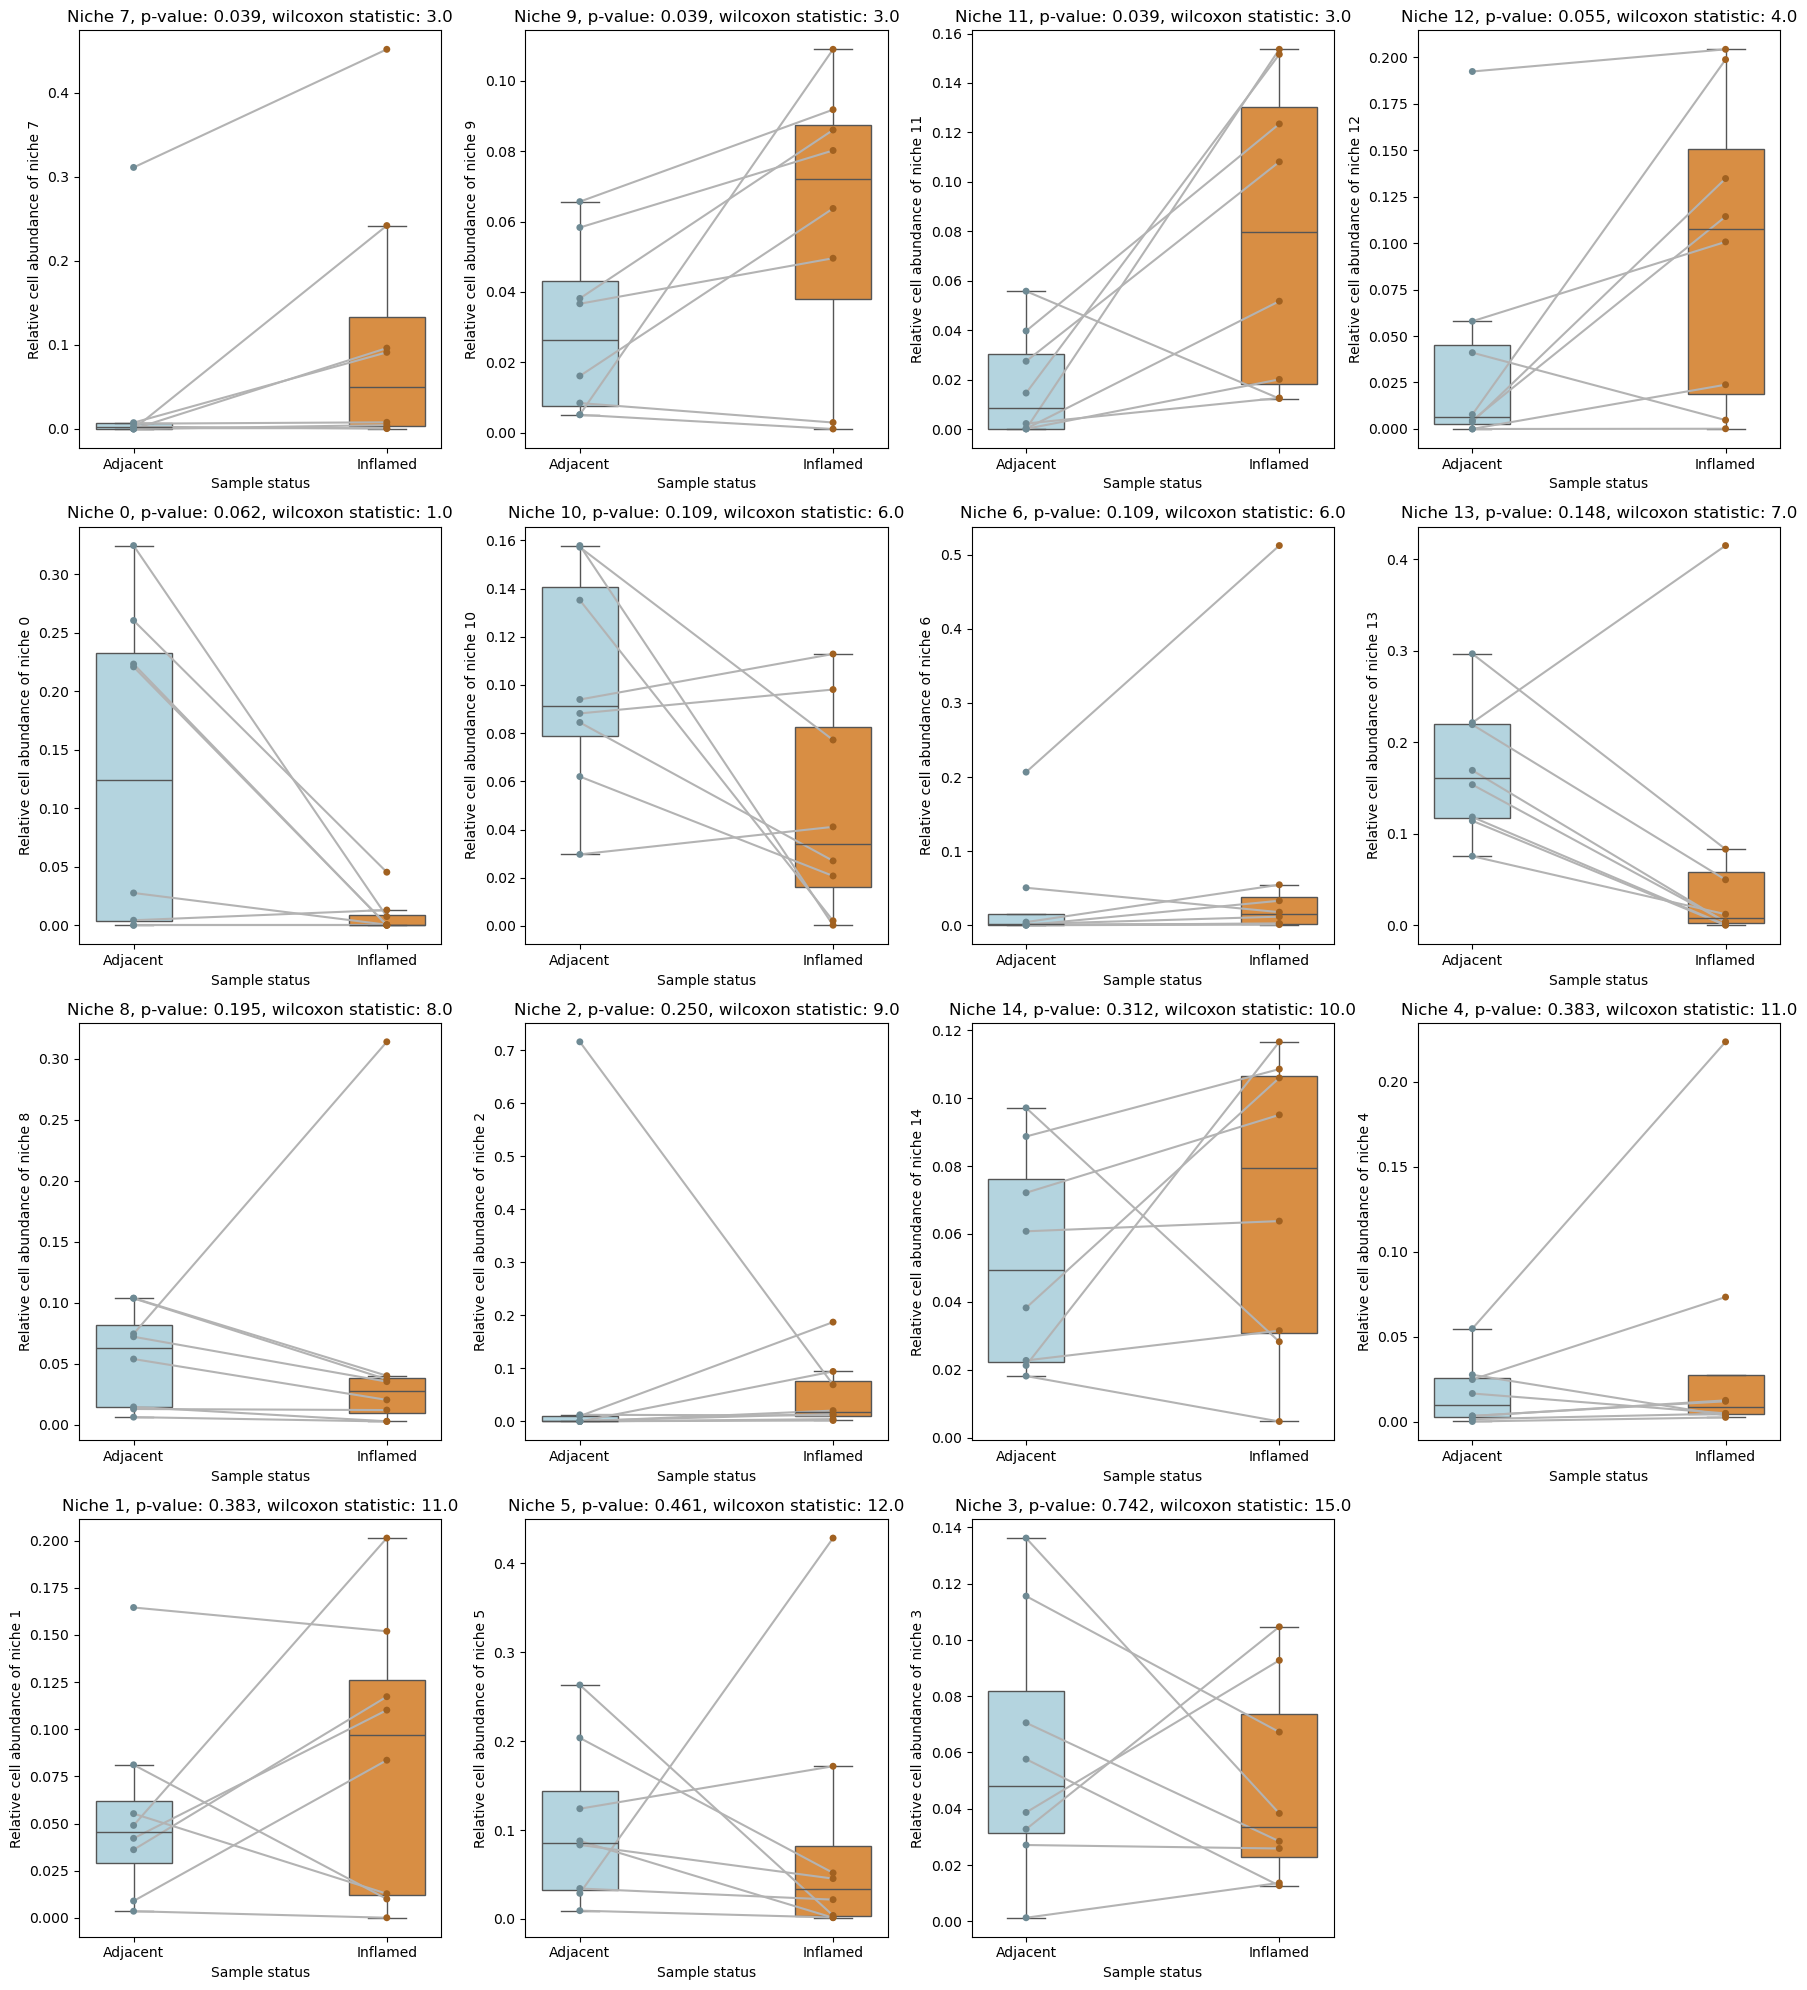

In [26]:
subplots_np(niche_order = niches_significance_nonp_sorting)

## All boxplots in one plot ordered according to wilcoxon p-value

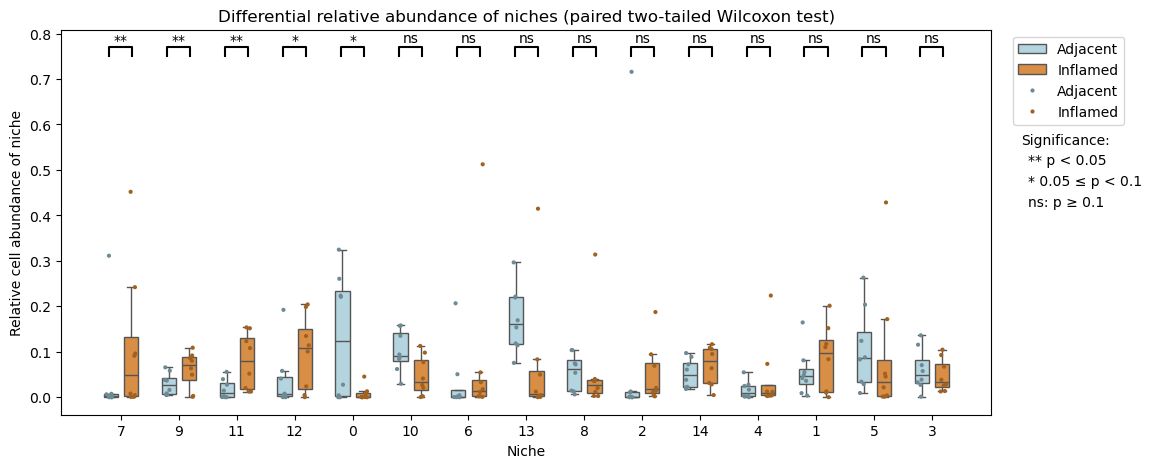

In [27]:
fig, ax = plt.subplots(figsize=(12,5))

plot = sns.boxplot(data=cross_melt,
                    x="Niche",
                    y="Proportion of niche",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "Status",
                    width=0.7,
                    gap = 0.3,
                    ax = ax, 
                    order = niches_significance_nonp_sorting,
                    hue_order=["Adjacent", "Inflamed"],
                    fliersize = 0,
                    #linecolor = "black"
                )
            
sns.stripplot(data=cross_melt, 
                    x="Niche", 
                    y="Proportion of niche",
                    palette= {"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    size = 3,
                    hue="Status", 
                    dodge=True, 
                    ax=ax,
                    order = niches_significance_nonp_sorting,
                    hue_order=["Adjacent", "Inflamed"],
                    )

plot.set_ylabel(f"Relative cell abundance of niche")

x = 1.15

first_legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(x,1.0)
)

for i, niche in enumerate(niches_significance_nonp_sorting):
    x1 = i - 0.2
    x2 = i + 0.2
    y =  0.75 
    h = 0.02
    col = "k"
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    if niche_stats_df_nonp.loc[niche, "p_value"] < 0.05:  
        text = "**"
        h2 = h
    elif niche_stats_df_nonp.loc[niche, "p_value"] < 0.1:  
        text = "*"
        h2 = h
    elif niche_stats_df_nonp.loc[niche, "p_value"] >= 0.1:  
        text = "ns"
        h2 = 0.025
    ax.text(i,y+h2,text,ha="center", va = "bottom", c = col)

line1, = ax.plot([], [], alpha = 0, label='** p < 0.05')
line2, = ax.plot([], [], alpha = 0, label='* 0.05 ≤ p < 0.1')
line3, = ax.plot([], [], alpha = 0, label='ns: p ≥ 0.1')

second_legend = plt.legend(handles=[line1, line2, line3],title = "Significance:",loc='lower right', bbox_to_anchor = (x+0.025, 0.5), frameon=False)

ax.add_artist(first_legend)

#table = pd.plotting.table(axes[1], niche_stats_df_nonp_sorted.round(3), loc="center", cellLoc="center")

plot.set_title(f"Differential relative abundance of niches (paired two-tailed Wilcoxon test)") 

plt.savefig(f"{path}/boxplot/boxplot_all_clusters_one_plot_nonp.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")

# Boxplots for celltypes

In [28]:

cross_c = pd.crosstab(sample.values, celltype.values, rownames = ["samples"], colnames=["cell_types"], normalize = "index")

for sample_id in cross_c.index:
    if sample_id in inf:
        cross_c.loc[f"{sample_id}","status"] = "Inflamed"
    else:
        cross_c.loc[f"{sample_id}","status"] = "Adjacent"

cross_c

cell_types,B_memory,B_plasma_IgA1,Neuron,CLEC9Ahi DC,CCL19hi DC,DC_pDC,Lymphatic endothelium,SELPhi endothelium,Absorptive enterocyte,Glial cell,...,TH-17,T_CD4_CM,T_CD4_Cycling,T_CD4_EM,T_CD8_EM,T_CD8_TE,T_G/D,T_Reg,SM MCAMhi perivascular muscle,status
samples,,,,,,,,,,,,,,,,,,,,,
0033516_adjacent,0.011236,0.019221,0.003389,0.005525,0.000302,0.000081,0.005989,0.082909,0.306297,0.032453,...,0.000708,0.001532,0.000371,0.000894,0.003053,0.002588,0.001509,0.000487,0.020742,Adjacent
0033516_affected,0.103151,0.148512,0.001759,0.005566,0.004412,0.001433,0.008308,0.080974,0.080808,0.029419,...,0.004690,0.055552,0.004400,0.006644,0.015527,0.012335,0.005484,0.008302,0.018097,Inflamed
0043587_adjacent,0.005446,0.003709,0.004065,0.002802,0.000276,0.000158,0.014088,0.051182,0.273351,0.047630,...,0.001578,0.002052,0.001105,0.006906,0.001894,0.001144,0.001618,0.000197,0.011404,Adjacent
0043587_affected,0.130469,0.103820,0.001784,0.006331,0.012786,0.007493,0.004833,0.097904,0.047408,0.016860,...,0.012896,0.079208,0.011320,0.020999,0.011398,0.012728,0.006669,0.011035,0.008998,Inflamed
0054175__GI10072_CD_adj,0.007186,0.024731,0.001410,0.003932,0.000258,0.000136,0.002712,0.052322,0.488496,0.017599,...,0.000637,0.001369,0.000298,0.001139,0.002807,0.000285,0.000719,0.000217,0.005966,Adjacent
0054175__GI_10072_CD_inf,0.039498,0.048302,0.002461,0.003328,0.002047,0.000187,0.016484,0.081520,0.272940,0.025639,...,0.004086,0.009398,0.000953,0.003023,0.007773,0.003297,0.001242,0.001062,0.009976,Inflamed
0054433__GI9676_CD_adj,0.088833,0.172070,0.001255,0.006265,0.013324,0.002775,0.007831,0.046167,0.127803,0.013105,...,0.013243,0.059652,0.017216,0.007128,0.008533,0.020844,0.002867,0.012621,0.007439,Adjacent
0054433__GI9676_CD_inf,0.121828,0.253173,0.001012,0.006706,0.014975,0.003685,0.005478,0.046168,0.064519,0.013176,...,0.016208,0.093102,0.021625,0.006624,0.011054,0.032915,0.002086,0.015314,0.010977,Inflamed
0060032__gi9662_inf,0.051872,0.031666,0.002662,0.008102,0.003687,0.001852,0.011840,0.074121,0.109896,0.038478,...,0.007152,0.069640,0.004018,0.012162,0.015105,0.011112,0.007755,0.003696,0.015188,Inflamed


In [29]:
cross_c_melt = cross_c.melt(
    id_vars=["status"],
    value_name="Proportion of cell type",
    ignore_index = False
)

cross_c_melt = cross_c_melt.rename(columns = {"status":"Status"})

cross_c_melt

,Status,cell_types,Proportion of cell type
samples,,,
0033516_adjacent,Adjacent,B_memory,0.011236
0033516_affected,Inflamed,B_memory,0.103151
0043587_adjacent,Adjacent,B_memory,0.005446
0043587_affected,Inflamed,B_memory,0.130469
0054175__GI10072_CD_adj,Adjacent,B_memory,0.007186
...,...,...,...
0060032__gi10056_nor,Adjacent,SM MCAMhi perivascular muscle,0.024978
0072732__CD10500INF,Inflamed,SM MCAMhi perivascular muscle,0.002355
0072732__CD10500NOR,Adjacent,SM MCAMhi perivascular muscle,0.004969


In [30]:
celltypes = adata.obs["annot"].cat.categories.tolist()

In [31]:
celltype_stats_df = pd.DataFrame(columns=["cell_type", "p_value", "t_statistic", "mean_inflamed", "mean_not_inflamed"])

for row, i in enumerate(celltypes):
    celltype = cross_c.loc[:,[f"{i}","status"]]
    
    celltype_inf = celltype[celltype["status"] == "Inflamed"][f"{i}"].to_numpy() 

    celltype_not_inf = celltype[celltype["status"] == "Adjacent"][f"{i}"].to_numpy() 

    t_statistic, p_value = stats.ttest_rel(celltype_inf, celltype_not_inf)

    mean_celltype_inf = round(celltype_inf.mean(),3)
    mean_celltype_not_inf = round(celltype_not_inf.mean(), 3)

    celltype_stats_df.loc[row] = [i, p_value, t_statistic, mean_celltype_inf, mean_celltype_not_inf]

celltype_stats_df

,cell_type,p_value,t_statistic,mean_inflamed,mean_not_inflamed
0,B_memory,0.396553,0.902963,0.108,0.070
1,B_plasma_IgA1,0.050626,2.356167,0.086,0.043
2,Neuron,0.293081,-1.136684,0.002,0.003
3,CLEC9Ahi DC,0.207998,1.387009,0.006,0.006
4,CCL19hi DC,0.166010,1.546058,0.007,0.004
5,DC_pDC,0.190618,1.448972,0.002,0.001
6,Lymphatic endothelium,0.983909,0.020899,0.007,0.007
7,SELPhi endothelium,0.374524,0.948370,0.068,0.057
8,Absorptive enterocyte,0.016748,-3.124092,0.128,0.252
9,Glial cell,0.853362,-0.191776,0.024,0.026


In [32]:
celltype_stats_df_sorted = celltype_stats_df.sort_values(by = "t_statistic", ascending = False, key = abs)
celltype_stats_df_sorted

,cell_type,p_value,t_statistic,mean_inflamed,mean_not_inflamed
38,T_CD8_EM,0.001334,5.143097,0.016,0.007
8,Absorptive enterocyte,0.016748,-3.124092,0.128,0.252
33,transit amplifying epithelium,0.016768,-3.123205,0.013,0.046
21,M COL4A1hi pericryptal fibroblast,0.024204,-2.863854,0.005,0.013
39,T_CD8_TE,0.031763,2.675124,0.010,0.004
37,T_CD4_EM,0.033078,2.647151,0.011,0.006
20,M ADAMDEChi fibroblast,0.033221,-2.644194,0.015,0.036
41,T_Reg,0.034366,2.620868,0.007,0.003
29,M COL7A1hi inflammatory fibroblast,0.046449,2.414753,0.006,0.001
16,SM GREM1hi fibrotic muscle,0.047536,2.398999,0.011,0.007


In [33]:
celltypes_significance_sorting = celltype_stats_df_sorted["cell_type"].tolist()

celltypes_significance_sorting

['T_CD8_EM',
 'Absorptive enterocyte',
 'transit amplifying epithelium',
 'M COL4A1hi pericryptal fibroblast',
 'T_CD8_TE',
 'T_CD4_EM',
 'M ADAMDEChi fibroblast',
 'T_Reg',
 'M COL7A1hi inflammatory fibroblast',
 'SM GREM1hi fibrotic muscle',
 'B_plasma_IgA1',
 'SM CCL19hi FRC-like fibroblast',
 'T_CD4_Cycling',
 'MM NR4A1hi muscle',
 'CCL19hi DC',
 'SM&M CCL19hi pericyte',
 'T_G/D',
 'DC_pDC',
 'CLEC9Ahi DC',
 'TH-17',
 'SM CA12hi universal fibroblast',
 'SM TNChi fibrotic myofibroblast',
 'Neuron',
 'SM&M PDGFRBhi pericyte',
 'SELPhi endothelium',
 'Monocyte',
 'ENS undefined',
 'B_memory',
 'Macrophage',
 'CD14hi macrophage',
 'S SOCS3hi fibroblast',
 'CMP SYNMhi muscle',
 'LMP NR4A1hi muscle',
 'SM GREM1hi fibroblast',
 'Mast',
 'SM MCAMhi perivascular muscle',
 'MP DPThi fibroblast',
 'Goblet cell',
 'Glial cell',
 'CMP GREM1hi muscle',
 'T_CD4_CM',
 'SM PI16hi universal fibroblast',
 'Lymphatic endothelium']

In [34]:
cross_c_melt

,Status,cell_types,Proportion of cell type
samples,,,
0033516_adjacent,Adjacent,B_memory,0.011236
0033516_affected,Inflamed,B_memory,0.103151
0043587_adjacent,Adjacent,B_memory,0.005446
0043587_affected,Inflamed,B_memory,0.130469
0054175__GI10072_CD_adj,Adjacent,B_memory,0.007186
...,...,...,...
0060032__gi10056_nor,Adjacent,SM MCAMhi perivascular muscle,0.024978
0072732__CD10500INF,Inflamed,SM MCAMhi perivascular muscle,0.002355
0072732__CD10500NOR,Adjacent,SM MCAMhi perivascular muscle,0.004969


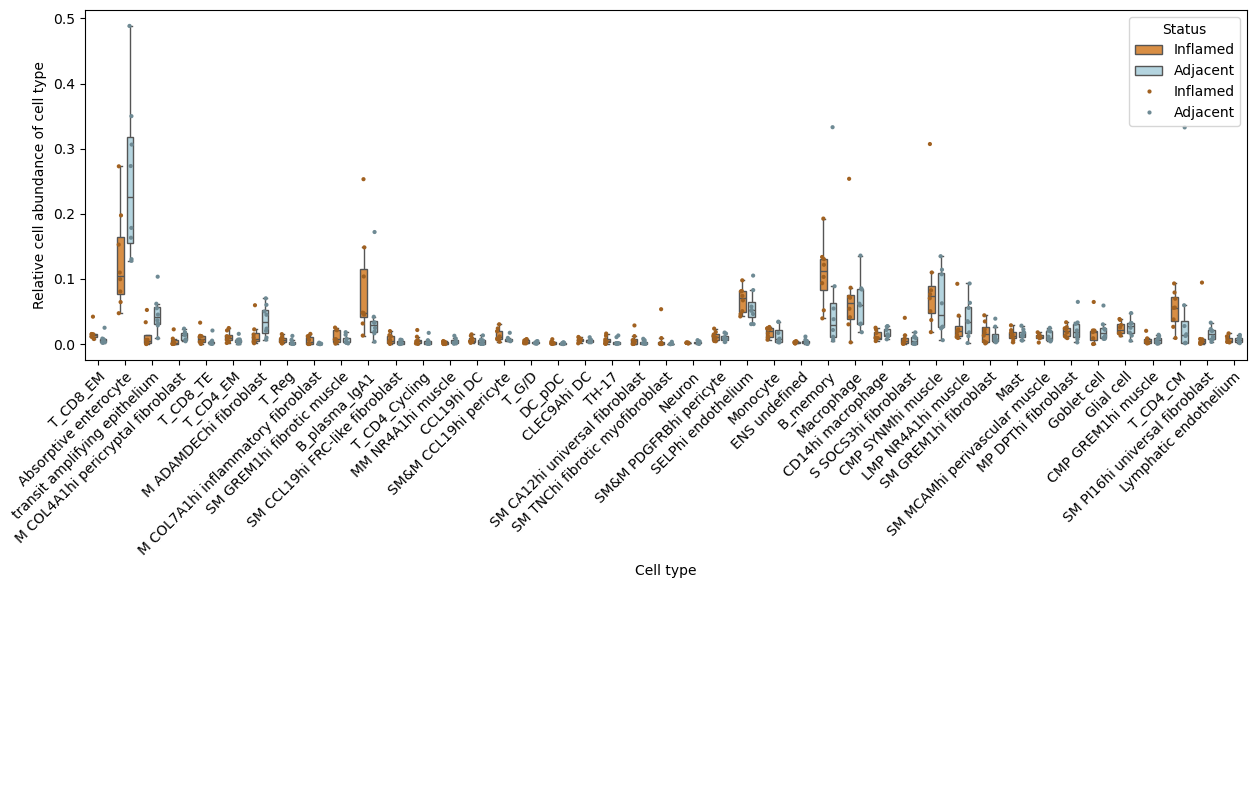

In [35]:
fig, axes = plt.subplots(2,1,figsize=(15,10))

axes = axes.flatten()

plot = sns.boxplot(data=cross_c_melt,
                    x="cell_types",
                    y="Proportion of cell type",
                    palette={"Adjacent": "#ADD8E6", "Inflamed": "#F18E2B"},
                    hue = "Status",
                    width=0.7,
                    gap = 0.3,
                    ax = axes[0], 
                    order = celltypes_significance_sorting,
                    hue_order=["Inflamed", "Adjacent"],
                    fliersize = 0,
                    #linecolor = "black"
                )
            
sns.stripplot(data=cross_c_melt, 
                    x="cell_types", 
                    y="Proportion of cell type",
                    palette= {"Adjacent": "#6E8A94", "Inflamed": "#A16120"},
                    size = 3,
                    hue="Status", 
                    dodge=True, 
                    ax=axes[0],
                    order = celltypes_significance_sorting,
                    hue_order=["Inflamed", "Adjacent"]
                    )

plot.set_ylabel(f"Relative cell abundance of cell type")
plot.set_xlabel("Cell type")

labels = axes[0].get_xticklabels()
plt.setp(labels, rotation=45, rotation_mode='anchor', ha='right', va='top')

#table = pd.plotting.table(axes[1], celltype_stats_df_sorted.round(3), loc="bottom", cellLoc="center", colWidths = [0.2,0.1,0.1,0.1,0.1])

axes[1].axis("off")

plt.savefig(f"{path}/boxplot/boxplot_all_celltypes_one_plot.png", dpi = 300, bbox_inches = "tight")